# 01 EDA

Purpose: inspect raw NUS modules and MyCareersFuture job ads before any filtering.

Inputs:
- `data/modules.csv`
- `data/MyCareersFutureData/*.json`

Outputs:
- `data/interim/jobs_raw.parquet`
- `data/interim/eda_modules_profile.csv`
- `data/interim/eda_jobs_summary.csv`


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore')
repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from analysis.io import paths, require_files

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

from analysis.preprocessing import build_jobs_summary, build_module_profile, clean_modules, load_raw_jobs

require_files([paths.modules_csv, paths.jobs_dir, paths.degree_map_csv, paths.module_skills_csv])
print(f'Repo root: {paths.repo_root}')
print(f'Outputs will be written under: {paths.data_dir}')


Repo root: /Users/marcusyeo/Github/DSA4264-Text-Group-3
Outputs will be written under: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data


In [2]:
modules_raw = pd.read_csv(paths.modules_csv)
if paths.jobs_raw_parquet.exists():
    jobs_raw = pd.read_parquet(paths.jobs_raw_parquet)
    job_files = sorted(paths.jobs_dir.glob('*.json'))
    print(f'Loaded cached raw jobs from: {paths.jobs_raw_parquet}')
else:
    jobs_raw, job_files = load_raw_jobs(paths.jobs_dir)
    jobs_raw.to_parquet(paths.jobs_raw_parquet, index=False)
    print(f'Parsed {len(job_files):,} raw job files and cached them to: {paths.jobs_raw_parquet}')

print(f'Modules shape: {modules_raw.shape}')
print(f'Raw jobs shape: {jobs_raw.shape}')
display(modules_raw.head(3))
display(jobs_raw.head(3))


Parsed 22,720 raw job files and cached them to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/interim/jobs_raw.parquet
Modules shape: (7014, 14)
Raw jobs shape: (22720, 16)


,moduleCode,title,acadYear,faculty,department,moduleCredit,description,additionalInformation,workload,gradingBasisDescription,preclusion,prerequisite,corequisite,semestersOffered
0,ABM5001,Leadership in Biomedicine,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,Leadership is fundamental to the success of in...,NaN,3/0/0/4/3,Graded,NaN,NaN,NaN,2
1,ABM5002,Advanced Biostatistics for Research,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,This course is served as a concept-based intro...,NaN,1.5/0.5/0/0/3,Graded,NaN,NaN,NaN,2
2,ABM5003,Biomedical Innovation & Enterprise,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,This course will furnish students with a thoro...,NaN,1.5/1.5/0/3/4,Graded,NaN,NaN,NaN,1


,job_id,title,description_raw,skills,skills_str,categories,categories_str,position_levels,employment_types,ssoc_code,salary_min,salary_max,salary_type,company,posted_date,expiry_date
0,ATS-2026-0184172,"Assistant Manager, Corporate Communications",<p><strong>Job Summary: </strong></p><p>This r...,"[Multimedia, Social Media, Strategic Communica...","Multimedia, Social Media, Strategic Communicat...",[Marketing / Public Relations],Marketing / Public Relations,[Junior Executive],[Permanent],24320,5500,7500,Monthly,CITY DEVELOPMENTS LIMITED,2026-01-29,2026-02-28
1,ATS-2026-0190206,Manager (Facilities Management),<p><strong >Role Overview</strong></p><p>We ar...,"[Fire Safety, Management Skills, Sustainabilit...","Fire Safety, Management Skills, Sustainability...",[Real Estate / Property Management],Real Estate / Property Management,[Manager],[Permanent],12191,7000,9000,Monthly,NTUC FAIRPRICE CO-OPERATIVE LTD,2026-01-30,2026-03-01
2,MCF-2025-1100407,Sales Administrator,<ul>\n <li>Serve as administrator / key opera...,"[Sales, Microsoft Office, Microsoft Excel, Tra...","Sales, Microsoft Office, Microsoft Excel, Trav...","[Hospitality, Sales / Retail]","Hospitality, Sales / Retail",[Executive],[Full Time],33224,3000,3200,Monthly,THE FULLERTON HOTEL,2026-01-25,2026-02-24


In [3]:
module_profile = build_module_profile(modules_raw)
modules_clean = clean_modules(modules_raw)
dept_coverage = (
    modules_clean[modules_clean['is_undergrad']]
    .groupby('department')
    .size()
    .reset_index(name='n_modules')
    .sort_values('n_modules', ascending=False)
)
module_profile.to_csv(paths.module_profile_summary_csv)

print(f'Clean modules with usable descriptions: {len(modules_clean):,}')
print(f'Undergraduate modules: {int(modules_clean["is_undergrad"].sum()):,}')
print(f'Module EDA summary saved to: {paths.module_profile_summary_csv}')
display(module_profile.head(15))
display(dept_coverage.head(15))


Clean modules with usable descriptions: 6,729
Undergraduate modules: 4,031
Module EDA summary saved to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/interim/eda_modules_profile.csv


,dtype,non_null_count,missing_count,missing_pct,n_unique
additionalInformation,str,89,6925,98.73,61
corequisite,str,105,6909,98.50,81
prerequisite,str,2967,4047,57.70,2170
preclusion,str,3037,3977,56.70,2826
workload,str,6803,211,3.01,949
description,str,6867,147,2.10,5403
moduleCode,str,7014,0,0.00,7014
title,str,7014,0,0.00,5181
department,str,7014,0,0.00,92
moduleCredit,float64,7014,0,0.00,27


,department,n_modules
74,Yale-NUS College,245
73,YSTCM Dean's Office,239
62,SCALE Dean's Office,174
46,NUS College Dean's Office,162
30,FoL Dean's Office,151
7,Biological Sciences,120
56,Political Science,118
43,Mathematics,117
57,Psychology,110
13,Centre for Language Studies,107


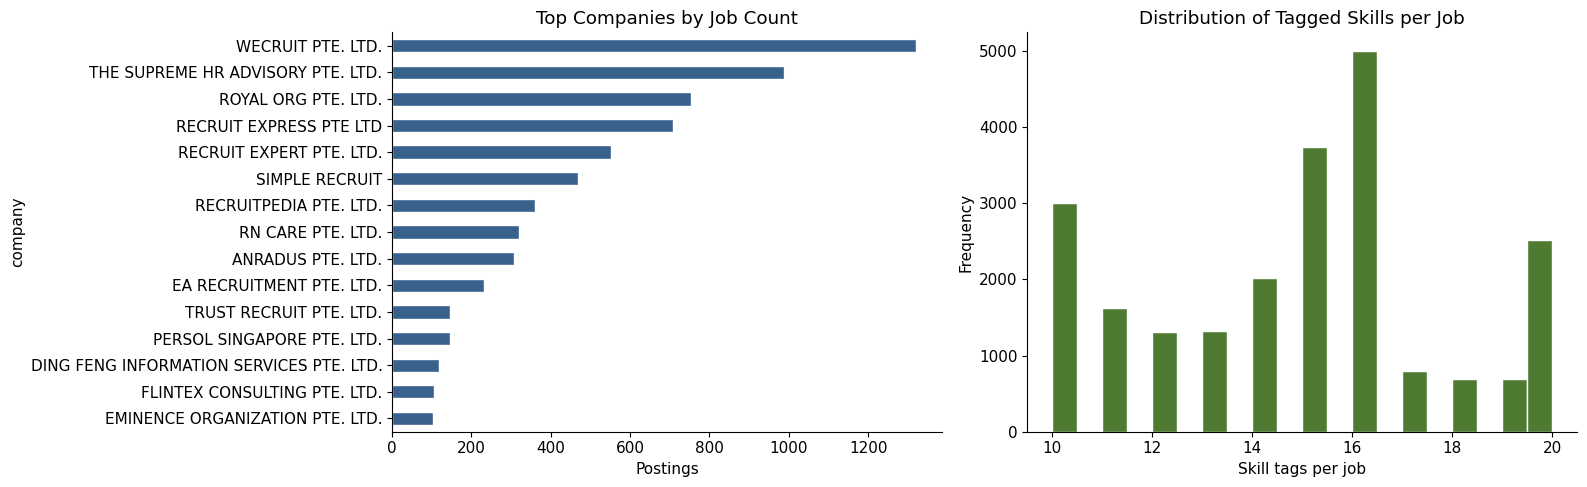

Job EDA summary saved to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/interim/eda_jobs_summary.csv


,metric,value
0,total_job_postings,22720.0
1,unique_job_titles,14996.0
2,unique_companies,5377.0
3,unique_categories,43.0
4,total_skill_tags,334729.0
5,unique_skills,9491.0
6,median_skills_per_job,15.0
7,jobs_without_tagged_skills,0.0


In [4]:
jobs_eda = jobs_raw.copy()
for column in ['categories', 'skills', 'employment_types', 'position_levels']:
    jobs_eda[column] = jobs_eda[column].apply(lambda value: value if isinstance(value, list) else [])

jobs_eda['category_count'] = jobs_eda['categories'].apply(len)
jobs_eda['skill_count'] = jobs_eda['skills'].apply(len)
jobs_eda['employment_type_count'] = jobs_eda['employment_types'].apply(len)

job_summary = build_jobs_summary(jobs_eda)
job_summary.to_csv(paths.job_summary_csv, index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
jobs_eda['company'].fillna('Unknown').value_counts().head(15).sort_values().plot(kind='barh', ax=axes[0], color='#38618c', edgecolor='white')
axes[0].set_title('Top Companies by Job Count')
axes[0].set_xlabel('Postings')

jobs_eda['skill_count'].plot(kind='hist', bins=20, ax=axes[1], color='#4e7a32', edgecolor='white')
axes[1].set_title('Distribution of Tagged Skills per Job')
axes[1].set_xlabel('Skill tags per job')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Job EDA summary saved to: {paths.job_summary_csv}')
display(job_summary)
